# Study how calorimeter decay shower truth is processed

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
from pyedm4hep import EDM4hepEvent

## Roadmap

1. Load in keep_all, low_threshold, medium_threshold events
2. Find particle that is: [greater than 0.001 GeV, created inside tracker, left a hit] which is in the low_threshold event but not the keep_all event
3. Get its ancestors and descendants in the keep_all event
4. Print the decay chain back to the pion in the keep_all event
5. Understand if there was ANY behaviour that may have led it to being dropped in the medium threshold event


# Single Particle - No Energy Threshold

In [102]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [103]:
base_dir = "/global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests/"
event_num = 0

This is with the TC truth handler turned on, but with a tracker the size of the world volume. That is, we should see energy threshold effects, but not calorimeter decay collapse effects.

In [104]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_low_threshold/edm4hep.root"
low_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_low_threshold/edm4hep.root...
  Loaded 542 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


In [105]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_medium_threshold/edm4hep.root"
medium_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_medium_threshold/edm4hep.root...
  Loaded 210 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


In [106]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_keep_all/edm4hep.root"
keepall_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_keep_all/edm4hep.root...
  Loaded 10776 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


## Interrogating a Sample Particle

To diagnose the difference, we need to know:
- Take a particle produced in the tracker in low threshold that doesn't appear in high threshold, which is above 0.001 GeV

In [12]:
keepall_particles_df, keepall_daughters_df, keepall_parents_df = keepall_event["particles_df"], keepall_event["daughters_df"], keepall_event["parents_df"]
keepall_tracker_df, keepall_calo_hit_df, keepall_calo_contrib_df = keepall_event["tracker_df"], keepall_event["calo_hits_df"], keepall_event["calo_contrib_df"]

medium_particles_df, medium_daughters_df, medium_parents_df = medium_event["particles_df"], medium_event["daughters_df"], medium_event["parents_df"]
medium_tracker_df, medium_calo_hit_df, medium_calo_contrib_df = medium_event["tracker_df"], medium_event["calo_hits_df"], medium_event["calo_contrib_df"]

low_particles_df, low_daughters_df, low_parents_df = low_event["particles_df"], low_event["daughters_df"], low_event["parents_df"]
low_tracker_df, low_calo_hit_df, low_calo_contrib_df = low_event["tracker_df"], low_event["calo_hits_df"], low_event["calo_contrib_df"]

In [22]:
low_sample = 17

In [25]:
keepall_sample = keepall_particles_df[(keepall_particles_df.time == low_particles_df.loc[low_sample].time) & (keepall_particles_df.p == low_particles_df.loc[low_sample].p)].index[0]
medium_sample = medium_particles_df[(medium_particles_df.time == low_particles_df.loc[low_sample].time) & (medium_particles_df.p == low_particles_df.loc[low_sample].p)].index[0]

In [ ]:
keepall_G = build_decay_tree(keepall_particles_df, keepall_daughters_df)
print(f"Built graph with {keepall_G.number_of_nodes()} nodes and {keepall_G.number_of_edges()} edges")

medium_G = build_decay_tree(medium_particles_df, medium_daughters_df)
print(f"Built graph with {medium_G.number_of_nodes()} nodes and {medium_G.number_of_edges()} edges")

low_G = build_decay_tree(low_particles_df, low_daughters_df)
print(f"Built graph with {low_G.number_of_nodes()} nodes and {low_G.number_of_edges()} edges")

In [ ]:
keepall_sample

In [ ]:
keepall_ancestors = list(nx.ancestors(keepall_G, keepall_sample))
keepall_descendants = list(nx.descendants(keepall_G, keepall_sample))

plt.figure(figsize=(10, 10))
plt.scatter(keepall_particles_df.loc[keepall_ancestors].vz, keepall_particles_df.loc[keepall_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(keepall_particles_df.loc[keepall_descendants].vz, keepall_particles_df.loc[keepall_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(keepall_particles_df.loc[keepall_sample].vz, keepall_particles_df.loc[keepall_sample].vr, c="green", s=10, marker="x", label="Sample particle")

for ancestor in keepall_ancestors:
    plt.text(keepall_particles_df.loc[ancestor].vz, keepall_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in keepall_descendants:
    plt.text(keepall_particles_df.loc[descendant].vz, keepall_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')



In [ ]:
low_ancestors = list(nx.ancestors(low_G, low_sample))
low_descendants = list(nx.descendants(low_G, low_sample))

plt.figure(figsize=(10, 10))
plt.scatter(low_particles_df.loc[low_ancestors].vz, low_particles_df.loc[low_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(low_particles_df.loc[low_descendants].vz, low_particles_df.loc[low_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(low_particles_df.loc[low_sample].vz, low_particles_df.loc[low_sample].vr, c="green", s=10, marker="x", label="Sample particle")

for ancestor in low_ancestors:
    plt.text(low_particles_df.loc[ancestor].vz, low_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in low_descendants:
    plt.text(low_particles_df.loc[descendant].vz, low_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')



In [ ]:
medium_ancestors = list(nx.ancestors(medium_G, medium_sample))
medium_descendants = list(nx.descendants(medium_G, medium_sample))

plt.figure(figsize=(10, 10))
plt.scatter(medium_particles_df.loc[medium_ancestors].vz, medium_particles_df.loc[medium_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(medium_particles_df.loc[medium_descendants].vz, medium_particles_df.loc[medium_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(medium_particles_df.loc[medium_sample].vz, medium_particles_df.loc[medium_sample].vr, c="green", s=10, marker="x", label="Sample particle")

for ancestor in medium_ancestors:
    plt.text(medium_particles_df.loc[ancestor].vz, medium_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in medium_descendants:
    plt.text(medium_particles_df.loc[descendant].vz, medium_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')



In [ ]:
ODD_particles_df[(ODD_particles_df.created_inside_tracker == 1) & (ODD_particles_df.p > 0.001) & (ODD_particles_df.index.isin(ODD_tracker_hits_df.particle_id))]

In [ ]:
ODD_particles_df[(ODD_particles_df.created_inside_tracker == 1) & (ODD_particles_df.p > 0.001)]

In [ ]:
ODD_medium_particles_df[(ODD_medium_particles_df.created_inside_tracker == 1) & (ODD_medium_particles_df.p > 0.001) & (ODD_medium_particles_df.index.isin(ODD_medium_tracker_hits_df.particle_id))]


In [ ]:
ODD_medium_particles_df[(ODD_medium_particles_df.created_inside_tracker == 1) & (ODD_medium_particles_df.pt > 0.001)]


In [ ]:
G

In [57]:
sample_particle = 17

In [ ]:
full_particles_df.loc[17]

In [ ]:
sample_medium_particle = ODD_medium_particles_df[ODD_medium_particles_df.p == full_particles_df.loc[17].p]
sample_medium_particle


In [ ]:
sample_medium_particle[["daughters_begin", "daughters_end"]]

In [ ]:
ODD_medium_daughters_df.iloc[61:64]

In [ ]:
ODD_medium_particles_df.iloc[122:125]

In [ ]:
ODD_particles_df.iloc[ODD_daughters_df.iloc[155:165].particle_id]

In [ ]:
ODD_daughters_df.iloc[155:165]

In [ ]:
ODD_medium_particles_df[ODD_medium_particles_df.p == ODD_particles_df.loc[295].p]

In [ ]:
ODD_particles_df.loc[295]

In [ ]:
get_simulator_status_bits(ODD_particles_df.loc[295].simulatorStatus)

In [ ]:
ODD_particles_df.iloc[294:305][["parents_begin", "parents_end"]]

In [ ]:
full_parents_df.iloc[293:304]

In [ ]:
ODD_calo_hits_df[ODD_calo_hits_df.particle_id.isin(ODD_daughters_df.iloc[155:165].particle_id)]

In [ ]:
descendants = list(nx.descendants(G, sample_particle))
ancestors = list(nx.ancestors(G, sample_particle))

plt.figure(figsize=(10, 10))
plt.scatter(full_particles_df.loc[ancestors].vz, full_particles_df.loc[ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(full_particles_df.loc[descendants].vz, full_particles_df.loc[descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(full_particles_df.loc[sample_particle].vz, full_particles_df.loc[sample_particle].vr, c="green", s=10, marker="x", label="Sample particle")

# Add text with the particle ID
plt.text(full_particles_df.loc[sample_particle].vz, full_particles_df.loc[sample_particle].vr, f"{sample_particle}", fontsize=12, ha='center')

for ancestor in ancestors:
    plt.text(full_particles_df.loc[ancestor].vz, full_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in descendants:
    plt.text(full_particles_df.loc[descendant].vz, full_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')

plt.legend()
plt.show()


In [ ]:
medium_sample_particle = 5
medium_descendants = list(nx.descendants(medium_G, medium_sample_particle))
medium_ancestors = list(nx.ancestors(medium_G, medium_sample_particle))

plt.figure(figsize=(10, 10))
plt.scatter(ODD_medium_particles_df.loc[medium_ancestors].vz, ODD_medium_particles_df.loc[medium_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(ODD_medium_particles_df.loc[medium_descendants].vz, ODD_medium_particles_df.loc[medium_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(ODD_medium_particles_df.loc[medium_sample_particle].vz, ODD_medium_particles_df.loc[medium_sample_particle].vr, c="green", s=10, marker="x", label="Sample particle")

# Add text with the particle ID
plt.text(ODD_medium_particles_df.loc[medium_sample_particle].vz, ODD_medium_particles_df.loc[medium_sample_particle].vr, f"{medium_sample_particle}", fontsize=12, ha='center')

for ancestor in medium_ancestors:
    plt.text(ODD_medium_particles_df.loc[ancestor].vz, ODD_medium_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in medium_descendants:
    plt.text(ODD_medium_particles_df.loc[descendant].vz, ODD_medium_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')

plt.legend()
plt.show()


## Comprehensive Study

### Compare KeepAll and LowThreshold

1. Start from the primary pion in the keep_all event, and in the low_threshold event
2. Look at immediate daughters of each
3. For each daughter, match between the events
4. Enumerate the following cases:
    - Daughter is present in both events' daughter set
    - Daughter is present in keep_all, but not in low_threshold daughters OR descendants
    - Daughter is present in low_threshold, but not in keep_all daughters OR descendants
    - Daughter is present in keep_all, and in low_threshold descendants
    - Daughter is present in low_threshold, and in keep_all descendants
5. Add each daughter to a list of that case
6. If a match is found, move to that daughter next, and repeat
7. Eventually, we will have iterated through all matching particles in the two events

In [13]:
start_particle_1 = keepall_event.get_particle(0)
start_particle_2 = low_event.get_particle(0)

In [14]:
start_particle_1, start_particle_2

(<Particle id=0 pdg=211 p=10.00 pT=7.51 eta=-0.79>,
 <Particle id=0 pdg=211 p=10.00 pT=7.51 eta=-0.79>)

In [15]:
daughters_p1 = start_particle_1.get_daughters()
daughters_p2 = start_particle_2.get_daughters()
set_daughters_p1 = set(daughters_p1)
set_daughters_p2 = set(daughters_p2)

descendants_p1 = start_particle_1.get_descendants()
descendants_p2 = start_particle_2.get_descendants()
set_descendants_p1 = set(descendants_p1)
set_descendants_p2 = set(descendants_p2)

Creating nodes for 10776 particles...
Creating edges based on parent-child relationships...
Created 10775 edges
Creating nodes for 542 particles...
Creating edges based on parent-child relationships...
Created 541 edges


In [16]:
len(set_daughters_p1), len(set_daughters_p2)

(42, 66)

In [17]:
matched_p2_daughters_found_via_p1 = set()

In [33]:
event1, event2 = keepall_event, low_event
queue = [(start_particle_1, start_particle_2)]
visited_pairs = set()
visited_pairs.add((hash(start_particle_1), hash(start_particle_2)))

results = {
        "matched_direct": [],
        "only_in_1": [],
        "only_in_2": [],
        "in_1_descendants_of_2": [], # Stores (p1_daughter, None)
        "in_2_descendants_of_1": [], # Stores (None, p2_daughter)
    }


In [34]:
for d1 in tqdm(daughters_p1):
    # Use event2's method to find a match for d1 anywhere in event2
    match_in_event_2 = event2.find_matching_particle(
        source_particle=d1,
    )

    if match_in_event_2:
        # A match for d1 exists in event2. Now check its relation to current_p2.
        if match_in_event_2 in set_daughters_p2:
            # Case: Direct daughter match
            results["matched_direct"].append((d1, match_in_event_2))
            matched_p2_daughters_found_via_p1.add(match_in_event_2)
            
            # Add the matched pair to the queue if not visited
            pair_hash = (hash(d1), hash(match_in_event_2))
            if pair_hash not in visited_pairs:
                queue.append((d1, match_in_event_2))
                visited_pairs.add(pair_hash)
                
        elif match_in_event_2 in set_descendants_p2:
            # Case: Match is a descendant of current_p2 (but not a direct daughter)
            results["in_1_descendants_of_2"].append((d1, match_in_event_2))
            # We don't add this pair to the queue, as the link is indirect for iteration
        else:
            # Case: Match exists in event2, but is NOT a daughter or descendant of current_p2
            # From the perspective of current_p1 -> current_p2 comparison, d1 is effectively unique.
            results["only_in_1"].append((d1, None))
    else:
        # Case: No match found for d1 anywhere in event2
        results["only_in_1"].append((d1, None))

for d2 in tqdm(daughters_p2):
    # Skip if d2 was already directly matched when processing d1's list
    if d2 in matched_p2_daughters_found_via_p1:
        continue

    # Use event1's method to find a match for d2 anywhere in event1
    match_in_event_1 = event1.find_matching_particle(
        source_particle=d2
    )

    if match_in_event_1:
        # A match for d2 exists in event1. Check its relation to current_p1.
        # We only care about the descendant case here, as direct matches were handled above.
        if match_in_event_1 in set_descendants_p1 and match_in_event_1 not in set_daughters_p1:
                # Case: Match is a descendant of current_p1 (and not a direct daughter)
                results["in_2_descendants_of_1"].append((match_in_event_1, d2))
        else:
                # Case: Match exists in event1 but is not a descendant (or was a direct daughter,
                # which implies d2 wasn't matched directly, so it's unique from p1's view).
                # Or match is unrelated to current_p1 lineage.
                results["only_in_2"].append((None, d2))
    else:
        # Case: No match found for d2 anywhere in event1
        results["only_in_2"].append((None, d2))

100%|██████████| 66/66 [00:00<00:00, 1571.19it/s]


In [35]:
print(f"Matched direct: {len(results['matched_direct'])}")
print(f"Only in 1: {len(results['only_in_1'])}")
print(f"Only in 2: {len(results['only_in_2'])}")
print(f"In 1 descendants of 2: {len(results['in_1_descendants_of_2'])}")
print(f"In 2 descendants of 1: {len(results['in_2_descendants_of_1'])}")


Matched direct: 20
Only in 1: 22
Only in 2: 0
In 1 descendants of 2: 0
In 2 descendants of 1: 46


In [21]:
results['in_2_descendants_of_1']

[(None, <Particle id=21 pdg=2112 p=0.03 pT=0.03 eta=-0.74>),
 (None, <Particle id=22 pdg=1000060120 p=0.05 pT=0.05 eta=-0.27>),
 (None, <Particle id=23 pdg=11 p=0.00 pT=0.00 eta=0.40>),
 (None, <Particle id=24 pdg=11 p=0.00 pT=0.00 eta=0.47>),
 (None, <Particle id=25 pdg=2212 p=0.03 pT=0.03 eta=0.12>),
 (None, <Particle id=26 pdg=2212 p=0.02 pT=0.01 eta=1.48>),
 (None, <Particle id=27 pdg=11 p=0.00 pT=0.00 eta=0.64>),
 (None, <Particle id=28 pdg=11 p=0.00 pT=0.00 eta=0.32>),
 (None, <Particle id=29 pdg=2112 p=0.03 pT=0.03 eta=0.57>),
 (None, <Particle id=32 pdg=1000140290 p=0.08 pT=0.07 eta=0.55>),
 (None, <Particle id=33 pdg=2212 p=0.06 pT=0.05 eta=-0.31>),
 (None, <Particle id=34 pdg=2212 p=0.02 pT=0.01 eta=-1.06>),
 (None, <Particle id=111 pdg=11 p=0.17 pT=0.16 eta=-0.46>),
 (None, <Particle id=112 pdg=-11 p=0.32 pT=0.29 eta=-0.46>),
 (None, <Particle id=155 pdg=11 p=0.02 pT=0.02 eta=-0.13>),
 (None, <Particle id=156 pdg=-11 p=0.21 pT=0.21 eta=-0.14>),
 (None, <Particle id=176 pdg=2

In [25]:
energies_of_2_descendants_of_1 = [p.p for p in [p[1] for p in tqdm(results['in_2_descendants_of_1'])]]
num_hits_of_2_descendants_of_1 = [p.get_num_hits() for p in [p[1] for p in tqdm(results['in_2_descendants_of_1'])]]


100%|██████████| 46/46 [00:00<00:00, 1083921.26it/s]


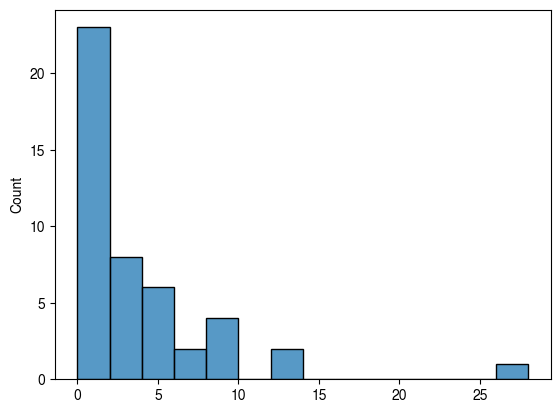

In [26]:
sns.histplot(num_hits_of_2_descendants_of_1)
plt.show()


<Axes: ylabel='Count'>

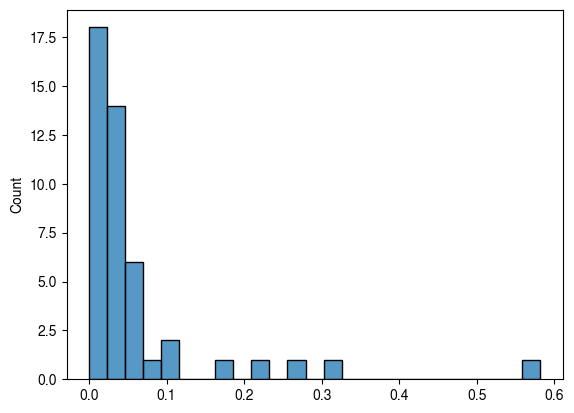

In [27]:
sns.histplot(energies_of_2_descendants_of_1)

In [29]:
results['only_in_1']

[(<Particle id=15 pdg=11 p=0.00 pT=0.00 eta=0.34>, None),
 (<Particle id=16 pdg=11 p=0.00 pT=0.00 eta=0.01>, None),
 (<Particle id=17 pdg=11 p=0.00 pT=0.00 eta=0.16>, None),
 (<Particle id=20 pdg=2112 p=0.63 pT=0.62 eta=0.17>, None),
 (<Particle id=23 pdg=111 p=1.10 pT=0.71 eta=-1.01>, None),
 (<Particle id=24 pdg=2112 p=0.54 pT=0.45 eta=-0.64>, None),
 (<Particle id=25 pdg=111 p=0.72 pT=0.68 eta=-0.35>, None),
 (<Particle id=27 pdg=1000020030 p=0.76 pT=0.70 eta=-0.40>, None),
 (<Particle id=28 pdg=1000010020 p=0.40 pT=0.36 eta=0.42>, None),
 (<Particle id=29 pdg=1000010020 p=0.44 pT=0.43 eta=0.24>, None),
 (<Particle id=30 pdg=1000010020 p=0.50 pT=0.42 eta=-0.62>, None),
 (<Particle id=31 pdg=2112 p=0.19 pT=0.16 eta=-0.60>, None),
 (<Particle id=32 pdg=2112 p=0.25 pT=0.25 eta=0.12>, None),
 (<Particle id=33 pdg=2212 p=0.30 pT=0.04 eta=2.82>, None),
 (<Particle id=34 pdg=1000010020 p=0.41 pT=0.36 eta=0.51>, None),
 (<Particle id=35 pdg=2212 p=0.16 pT=0.16 eta=0.04>, None),
 (<Particle 

In [37]:
for particle in results['only_in_1']:
    print(f"Particle {particle[0].id} has {particle[0].get_num_hits()} hits")


Particle 15 has 0 hits
Particle 16 has 0 hits
Particle 17 has 0 hits
Particle 20 has 0 hits
Particle 23 has 0 hits
Particle 24 has 0 hits
Particle 25 has 0 hits
Particle 27 has 0 hits
Particle 28 has 0 hits
Particle 29 has 0 hits
Particle 30 has 0 hits
Particle 31 has 0 hits
Particle 32 has 0 hits
Particle 33 has 0 hits
Particle 34 has 0 hits
Particle 35 has 0 hits
Particle 36 has 0 hits
Particle 37 has 0 hits
Particle 38 has 0 hits
Particle 39 has 0 hits
Particle 40 has 0 hits
Particle 41 has 0 hits


In [40]:
for particle in results['in_2_descendants_of_1']:
    print(f"Particle {particle[1].id} has {particle[1].get_num_hits()} hits, and start in tracker: {particle[1].created_inside_tracker}")

    # Test case: Either have >0 hits, OR started in the tracker
    print(f"Pass test: {particle[1].get_num_hits() > 0 or particle[1].created_inside_tracker}")

Particle 21 has 1 hits, and start in tracker: False
Pass test: True
Particle 22 has 0 hits, and start in tracker: True
Pass test: True
Particle 23 has 13 hits, and start in tracker: False
Pass test: True
Particle 24 has 1 hits, and start in tracker: True
Pass test: True
Particle 25 has 0 hits, and start in tracker: True
Pass test: True
Particle 26 has 0 hits, and start in tracker: True
Pass test: True
Particle 27 has 12 hits, and start in tracker: False
Pass test: True
Particle 28 has 3 hits, and start in tracker: False
Pass test: True
Particle 29 has 1 hits, and start in tracker: False
Pass test: True
Particle 32 has 1 hits, and start in tracker: False
Pass test: True
Particle 33 has 0 hits, and start in tracker: True
Pass test: True
Particle 34 has 0 hits, and start in tracker: True
Pass test: True
Particle 111 has 4 hits, and start in tracker: False
Pass test: True
Particle 112 has 2 hits, and start in tracker: False
Pass test: True
Particle 155 has 1 hits, and start in tracker: Fal

In [52]:
from typing import List, Optional, Tuple, Dict, Set

def compare_decay_chains_event_match(
    start_particle_1: 'Particle',
    event1: 'EDM4hepEvent',
    start_particle_2: 'Particle',
    event2: 'EDM4hepEvent',
    match_vars: Optional[List[str]] = None, # Variables for event.find_matching_particle
    tolerance: float = 1e-6                 # Tolerance for event.find_matching_particle
) -> Dict[str, List[Tuple[Optional['Particle'], Optional['Particle']]]]:
    """
    Compares the decay chains starting from two particles using event-level matching
    first, then categorizing based on daughter/descendant relationships.

    Args:
        start_particle_1: The starting particle from the first event/chain.
        event1: The EDM4hepEvent object containing start_particle_1.
        start_particle_2: The corresponding starting particle from the second event/chain.
        event2: The EDM4hepEvent object containing start_particle_2.
        match_vars (Optional[List[str]]): Variables to use for matching in
                                           event.find_matching_particle. Defaults to
                                           ['time', 'px', 'py', 'pz', 'pdg'] in the method.
        tolerance (float): Tolerance for float comparisons in
                           event.find_matching_particle. Defaults to 1e-6 in the method.

    Returns:
        A dictionary containing lists of categorized particles:
        - 'matched_direct': List of (p1, p2) tuples where p1 daughter matches p2 daughter.
        - 'only_in_1': List of (p1_daughter, None) where p1 daughter has no corresponding
                       match in p2's daughters or descendants.
        - 'only_in_2': List of (None, p2_daughter) where p2 daughter has no corresponding
                       match in p1's daughters or descendants.
        - 'in_1_descendants_of_2': List of (p1_daughter, p2_match) where p1 daughter's match
                                  in event2 is a descendant (not direct daughter) of p2.
        - 'in_2_descendants_of_1': List of (p1_match, p2_daughter) where p2 daughter's match
                                  in event1 is a descendant (not direct daughter) of p1.
        Note: The second element in the '...descendants...' tuples is the particle found by
              find_matching_particle, which might be useful context. We'll return
              (p1, None) and (None, p2) for simplicity as per the original request's structure.
    """

    results = {
        "matched_direct": [],
        "only_in_1": [],
        "only_in_2": [],
        "in_1_descendants_of_2": [], # Stores (p1_daughter, None)
        "in_2_descendants_of_1": [], # Stores (None, p2_daughter)
    }

    # Queue for iterative processing: stores tuples of (particle_from_1, particle_from_2)
    queue = [(start_particle_1, start_particle_2)]
    
    # Keep track of visited pairs to prevent infinite loops (using particle hashes)
    visited_pairs: Set[Tuple[int, int]] = set()
    visited_pairs.add((hash(start_particle_1), hash(start_particle_2)))

    while queue:
        current_p1, current_p2 = queue.pop(0)

        # --- Get daughters and descendants for the current pair ---
        daughters_p1 = current_p1.get_daughters()
        daughters_p2 = current_p2.get_daughters()
        
        # Using sets for efficient 'in' checks
        set_daughters_p1 = set(daughters_p1)
        set_daughters_p2 = set(daughters_p2)
        
        # Get descendants (can be slow, called once per pair)
        descendants_p1 = current_p1.get_descendants()
        descendants_p2 = current_p2.get_descendants()
        set_descendants_p1 = set(descendants_p1)
        set_descendants_p2 = set(descendants_p2)

        # Keep track of p2 daughters that were directly matched during p1 iteration
        matched_p2_daughters_found_via_p1: Set['Particle'] = set()

        # --- 1. Iterate through daughters of particle 1 ---
        for d1 in daughters_p1:
            # Use event2's method to find a match for d1 anywhere in event2
            match_in_event_2 = event2.find_matching_particle(
                source_particle=d1,
                match_vars=match_vars,
                tolerance=tolerance
            )

            if match_in_event_2:
                # A match for d1 exists in event2. Now check its relation to current_p2.
                if match_in_event_2 in set_daughters_p2:
                    # Case: Direct daughter match
                    results["matched_direct"].append((d1, match_in_event_2))
                    matched_p2_daughters_found_via_p1.add(match_in_event_2)
                    
                    # Add the matched pair to the queue if not visited
                    pair_hash = (hash(d1), hash(match_in_event_2))
                    if pair_hash not in visited_pairs:
                        queue.append((d1, match_in_event_2))
                        visited_pairs.add(pair_hash)
                        
                elif match_in_event_2 in set_descendants_p2:
                    # Case: Match is a descendant of current_p2 (but not a direct daughter)
                    results["in_1_descendants_of_2"].append((d1, match_in_event_2))
                    
                    # Add the matched pair to the queue if not visited
                    pair_hash = (hash(d1), hash(match_in_event_2))
                    if pair_hash not in visited_pairs:
                        queue.append((d1, match_in_event_2))
                        visited_pairs.add(pair_hash)
                else:
                    # Case: Match exists in event2, but is NOT a daughter or descendant of current_p2
                    # From the perspective of current_p1 -> current_p2 comparison, d1 is effectively unique.
                    results["only_in_1"].append((d1, None))
            else:
                # Case: No match found for d1 anywhere in event2
                results["only_in_1"].append((d1, None))

        # --- 2. Iterate through daughters of particle 2 ---
        for d2 in daughters_p2:
            # Skip if d2 was already directly matched when processing d1's list
            if d2 in matched_p2_daughters_found_via_p1:
                continue

            # Use event1's method to find a match for d2 anywhere in event1
            match_in_event_1 = event1.find_matching_particle(
                source_particle=d2,
                match_vars=match_vars,
                tolerance=tolerance
            )

            if match_in_event_1:
                # A match for d2 exists in event1. Check its relation to current_p1.
                # We only care about the descendant case here, as direct matches were handled above.
                if match_in_event_1 in set_descendants_p1 and match_in_event_1 not in set_daughters_p1:
                    # Case: Match is a descendant of current_p1 (and not a direct daughter)
                    results["in_2_descendants_of_1"].append((match_in_event_1, d2))

                    # Add the matched pair to the queue if not visited
                    pair_hash = (hash(match_in_event_1), hash(d2))
                    if pair_hash not in visited_pairs:
                        queue.append((match_in_event_1, d2))
                        visited_pairs.add(pair_hash)

                else:
                     # Case: Match exists in event1 but is not a descendant (or was a direct daughter,
                     # which implies d2 wasn't matched directly, so it's unique from p1's view).
                     # Or match is unrelated to current_p1 lineage.
                     results["only_in_2"].append((None, d2))
            else:
                # Case: No match found for d2 anywhere in event1
                results["only_in_2"].append((None, d2))

    return results

In [53]:
results = compare_decay_chains_event_match(start_particle_1, keepall_event, start_particle_2, low_event)

In [54]:
print(f"Matched direct: {len(results['matched_direct'])}")
print(f"Only in 1: {len(results['only_in_1'])}")
print(f"Only in 2: {len(results['only_in_2'])}")
print(f"In 1 descendants of 2: {len(results['in_1_descendants_of_2'])}")
print(f"In 2 descendants of 1: {len(results['in_2_descendants_of_1'])}")


Matched direct: 110
Only in 1: 1433
Only in 2: 0
In 1 descendants of 2: 0
In 2 descendants of 1: 431


In [55]:
keepall_event.get_particles_df()

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,10.000000,-0.793412,0.228517,0.000000,1198.486097,13,False,True,False,False
1,11,0,1358954496,-1.0,0.119643,0.000511,26.239766,6.073147,-23.682606,-0.000047,...,0.000086,-1.096881,-2.742373,26.933407,26.618292,0,True,True,True,False
2,11,0,1358954496,-1.0,0.147753,0.000511,32.407042,7.491403,-29.246157,-0.000080,...,0.000808,-2.390136,-2.148970,33.261652,34.056235,3,True,True,True,False
3,11,0,1358954496,-1.0,0.896818,0.000511,197.022015,44.181930,-177.484173,0.000024,...,0.000035,0.823012,-0.304031,201.915124,201.934549,0,True,True,True,False
4,11,0,1358954496,-1.0,1.788787,0.000511,393.659256,84.976011,-354.008063,0.000040,...,0.000063,0.532539,-0.750540,402.726374,402.877922,0,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10771,11,0,1090519040,-1.0,5.886012,0.000511,1306.725820,217.231200,-1160.506608,-0.000340,...,0.000374,-0.184224,2.755138,1324.659112,1324.657663,0,True,False,False,False
10772,11,0,1090519040,-1.0,5.892001,0.000511,1306.983919,218.734062,-1162.421240,-0.000326,...,0.000620,-1.167327,-2.759544,1325.160954,1325.157288,0,True,False,False,False
10773,11,0,1358954496,-1.0,4.234975,0.000511,922.953392,178.635507,-822.368282,0.000024,...,0.000050,-0.514241,-0.989205,940.081703,940.146991,0,True,True,True,False
10774,11,0,1358954496,-1.0,4.506058,0.000511,922.980109,178.993391,-832.482697,-0.000025,...,0.000033,-0.338790,-2.510286,940.176002,940.159108,0,True,True,True,False


In [56]:
low_event.get_particles_df()

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,10.000000,-0.793412,0.228517,0.000000,1198.486097,15,False,True,False,False
1,11,0,1493172224,-1.0,0.119643,0.000511,26.239766,6.073147,-23.682606,-0.000047,...,0.000086,-1.096881,-2.742373,26.933407,26.618292,0,True,True,True,False
2,11,0,1493172224,-1.0,0.147753,0.000511,32.407042,7.491403,-29.246157,-0.000080,...,0.000808,-2.390136,-2.148970,33.261652,34.056235,3,True,True,True,False
3,11,0,1493172224,-1.0,0.896818,0.000511,197.022015,44.181930,-177.484173,0.000024,...,0.000035,0.823012,-0.304031,201.915124,201.934549,0,True,True,True,False
4,11,0,1493172224,-1.0,1.788787,0.000511,393.659256,84.976011,-354.008063,0.000040,...,0.000063,0.532539,-0.750540,402.726374,402.877922,0,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,11,0,1426063360,-1.0,6.628668,0.000511,1443.979037,208.611240,-1286.866497,0.001014,...,0.001122,-0.394439,-0.222863,1458.970222,1459.372507,19,True,False,False,False
538,11,0,1426063360,-1.0,6.760890,0.000511,1464.401577,205.851635,-1303.040202,0.000596,...,0.000949,-0.995582,0.259867,1478.799132,1479.283694,6,True,False,False,False
539,11,0,1493172224,-1.0,4.234975,0.000511,922.953392,178.635507,-822.368282,0.000024,...,0.000050,-0.514241,-0.989205,940.081703,940.146991,0,True,True,True,False
540,11,0,1493172224,-1.0,4.506058,0.000511,922.980109,178.993391,-832.482697,-0.000025,...,0.000033,-0.338790,-2.510286,940.176002,940.159108,0,True,True,True,False


In [57]:
energies_of_2_descendants_of_1 = [p.p for p in [p[1] for p in tqdm(results['in_2_descendants_of_1'])]]
num_hits_of_2_descendants_of_1 = [p.get_num_hits() for p in [p[1] for p in tqdm(results['in_2_descendants_of_1'])]]


100%|██████████| 431/431 [00:00<00:00, 3696820.09it/s]


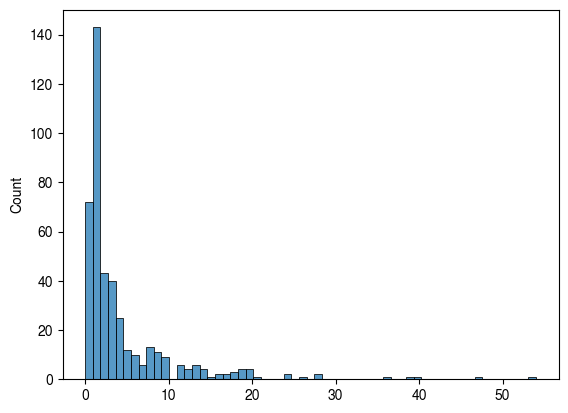

In [58]:
sns.histplot(num_hits_of_2_descendants_of_1)
plt.show()


<Axes: ylabel='Count'>

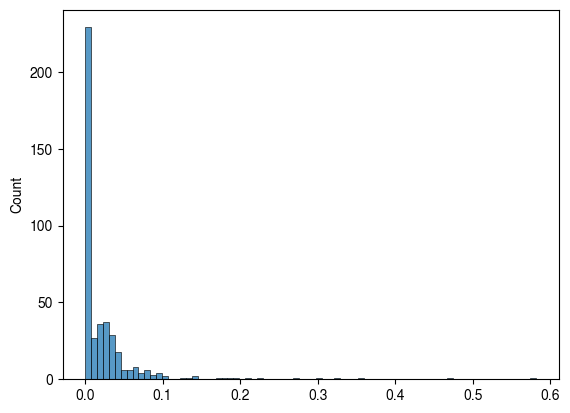

In [59]:
sns.histplot(energies_of_2_descendants_of_1)

In [60]:
for particle in results['only_in_1']:
    print(f"Particle {particle[0].id} has {particle[0].get_num_hits()} hits")


Particle 15 has 0 hits
Particle 16 has 0 hits
Particle 17 has 0 hits
Particle 20 has 0 hits
Particle 23 has 0 hits
Particle 24 has 0 hits
Particle 25 has 0 hits
Particle 27 has 0 hits
Particle 28 has 0 hits
Particle 29 has 0 hits
Particle 30 has 0 hits
Particle 31 has 0 hits
Particle 32 has 0 hits
Particle 33 has 0 hits
Particle 34 has 0 hits
Particle 35 has 0 hits
Particle 36 has 0 hits
Particle 37 has 0 hits
Particle 38 has 0 hits
Particle 39 has 0 hits
Particle 40 has 0 hits
Particle 41 has 0 hits
Particle 7940 has 0 hits
Particle 7941 has 0 hits
Particle 7943 has 0 hits
Particle 7944 has 0 hits
Particle 7946 has 0 hits
Particle 7947 has 0 hits
Particle 7948 has 0 hits
Particle 7949 has 0 hits
Particle 7950 has 0 hits
Particle 7951 has 0 hits
Particle 5896 has 0 hits
Particle 5897 has 0 hits
Particle 5898 has 0 hits
Particle 5902 has 0 hits
Particle 5903 has 0 hits
Particle 5904 has 0 hits
Particle 5905 has 0 hits
Particle 5909 has 0 hits
Particle 5910 has 0 hits
Particle 5911 has 0

In [62]:
all_pass = True

for particle in results['in_2_descendants_of_1']:
    print(f"Particle {particle[1].id} has {particle[1].get_num_hits()} hits, and start in tracker: {particle[1].created_inside_tracker}")

    # Test case: Either have >0 hits, OR started in the tracker
    passes_test = particle[1].get_num_hits() > 0 or particle[1].created_inside_tracker
    print(f"Pass test: {passes_test}")
    all_pass = all_pass and passes_test

print(f"All pass: {all_pass}")

Particle 21 has 1 hits, and start in tracker: False
Pass test: True
Particle 22 has 0 hits, and start in tracker: True
Pass test: True
Particle 23 has 13 hits, and start in tracker: False
Pass test: True
Particle 24 has 1 hits, and start in tracker: True
Pass test: True
Particle 25 has 0 hits, and start in tracker: True
Pass test: True
Particle 26 has 0 hits, and start in tracker: True
Pass test: True
Particle 27 has 12 hits, and start in tracker: False
Pass test: True
Particle 28 has 3 hits, and start in tracker: False
Pass test: True
Particle 29 has 1 hits, and start in tracker: False
Pass test: True
Particle 32 has 1 hits, and start in tracker: False
Pass test: True
Particle 33 has 0 hits, and start in tracker: True
Pass test: True
Particle 34 has 0 hits, and start in tracker: True
Pass test: True
Particle 111 has 4 hits, and start in tracker: False
Pass test: True
Particle 112 has 2 hits, and start in tracker: False
Pass test: True
Particle 155 has 1 hits, and start in tracker: Fal

### Compare LowThreshold and MediumThreshold

<Axes: xlabel='kinetic_energy', ylabel='Count'>

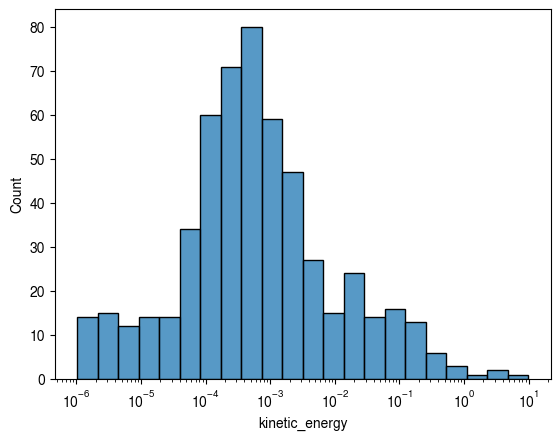

In [109]:
sns.histplot(low_event.get_particles_df().kinetic_energy, log_scale=True)

<Axes: xlabel='kinetic_energy', ylabel='Count'>

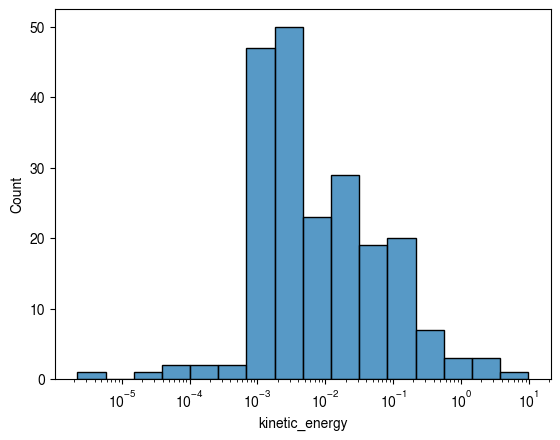

In [110]:
sns.histplot(medium_event.get_particles_df().kinetic_energy, log_scale=True)

In [111]:
start_particle_1 = low_event.get_particle(0)
start_particle_2 = medium_event.get_particle(0)

In [112]:
print(f"Start particle 1: {start_particle_1}, Start particle 2: {start_particle_2}")

Start particle 1: <Particle id=0 pdg=211 p=10.00 pT=7.51 eta=-0.79>, Start particle 2: <Particle id=0 pdg=211 p=10.00 pT=7.51 eta=-0.79>


In [113]:
results = compare_decay_chains_event_match(start_particle_1, low_event, start_particle_2, medium_event)

Creating nodes for 542 particles...
Creating edges based on parent-child relationships...
Created 541 edges
Creating nodes for 210 particles...
Creating edges based on parent-child relationships...
Created 209 edges


/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/physics/../pyedm4hep/decay.py:77: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  'PDG', 'pt', 'eta', 'phi']].to_dict('index')
/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/physics/../pyedm4hep/decay.py:77: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  'PDG', 'pt', 'eta', 'phi']].to_dict('index')


In [114]:
print(f"Matched direct: {len(results['matched_direct'])}")
print(f"Only in 1: {len(results['only_in_1'])}")
print(f"Only in 2: {len(results['only_in_2'])}")
print(f"In 1 descendants of 2: {len(results['in_1_descendants_of_2'])}")
print(f"In 2 descendants of 1: {len(results['in_2_descendants_of_1'])}")


Matched direct: 199
Only in 1: 288
Only in 2: 0
In 1 descendants of 2: 0
In 2 descendants of 1: 10


In [115]:
low_event.get_particles_df()

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,0.228517,0.000000,1198.486097,10.000974,9.861404,15,False,True,False,False
1,11,0,1493172224,-1.0,0.119643,0.000511,26.239766,6.073147,-23.682606,-0.000047,...,-2.742373,26.933407,26.618292,0.000518,0.000007,0,True,True,True,False
2,11,0,1493172224,-1.0,0.147753,0.000511,32.407042,7.491403,-29.246157,-0.000080,...,-2.148970,33.261652,34.056235,0.000956,0.000445,3,True,True,True,False
3,11,0,1493172224,-1.0,0.896818,0.000511,197.022015,44.181930,-177.484173,0.000024,...,-0.304031,201.915124,201.934549,0.000512,0.000001,0,True,True,True,False
4,11,0,1493172224,-1.0,1.788787,0.000511,393.659256,84.976011,-354.008063,0.000040,...,-0.750540,402.726374,402.877922,0.000515,0.000004,0,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,11,0,1426063360,-1.0,6.628668,0.000511,1443.979037,208.611240,-1286.866497,0.001014,...,-0.222863,1458.970222,1459.372507,0.001233,0.000722,19,True,False,False,False
538,11,0,1426063360,-1.0,6.760890,0.000511,1464.401577,205.851635,-1303.040202,0.000596,...,0.259867,1478.799132,1479.283694,0.001078,0.000567,6,True,False,False,False
539,11,0,1493172224,-1.0,4.234975,0.000511,922.953392,178.635507,-822.368282,0.000024,...,-0.989205,940.081703,940.146991,0.000513,0.000002,0,True,True,True,False
540,11,0,1493172224,-1.0,4.506058,0.000511,922.980109,178.993391,-832.482697,-0.000025,...,-2.510286,940.176002,940.159108,0.000512,0.000001,0,True,True,True,False


In [116]:
medium_event.get_particles_df()

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,0.228517,0.000000,1198.486097,10.000974,9.861404,112,False,True,False,False
1,11,0,1493172224,-1.0,0.147753,0.000511,32.407042,7.491403,-29.246157,-0.000080,...,-2.148970,33.261652,34.056235,0.000956,0.000445,3,True,True,True,False
2,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314568,-558.626150,0.002685,...,0.580828,635.488577,635.362217,0.003413,0.002902,0,True,True,True,False
3,-211,0,1157627904,-1.0,5.325320,0.139570,1178.951708,215.503585,-1053.953215,2.352287,...,0.017566,1198.486097,1348.317818,3.043472,2.903902,25,True,False,False,False
4,211,0,1157627904,1.0,5.325320,0.139570,1178.951708,215.503585,-1053.953215,1.045800,...,0.348931,1198.486097,1342.259772,1.731216,1.591646,165,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,11,0,1426063360,-1.0,1586.360596,0.000511,123.294458,1272.028830,-266.814390,0.002038,...,0.811154,1277.990168,1279.614465,0.003257,0.002746,2,True,False,False,False
206,2212,0,1426063360,1.0,8.013903,0.938272,1293.288009,377.869201,-1268.673419,-0.134606,...,-2.412295,1347.360014,1345.915404,0.958729,0.020457,3,True,False,False,False
207,2212,0,1157627904,1.0,6.356293,0.938272,1372.882592,180.820678,-1218.792661,0.282648,...,-0.960887,1384.739228,1405.401501,1.124602,0.186330,5,True,False,False,False
208,11,0,1426063360,-1.0,517.335266,0.000511,1362.870223,120.293118,-977.804045,0.001797,...,-0.210230,1368.168732,1368.858405,0.001937,0.001426,8,True,False,False,False


In [72]:
energies_of_2_descendants_of_1 = [p.p for p in [p[1] for p in tqdm(results['in_2_descendants_of_1'])]]
num_hits_of_2_descendants_of_1 = [p.get_num_hits() for p in [p[1] for p in tqdm(results['in_2_descendants_of_1'])]]


100%|██████████| 10/10 [00:00<00:00, 208671.84it/s]


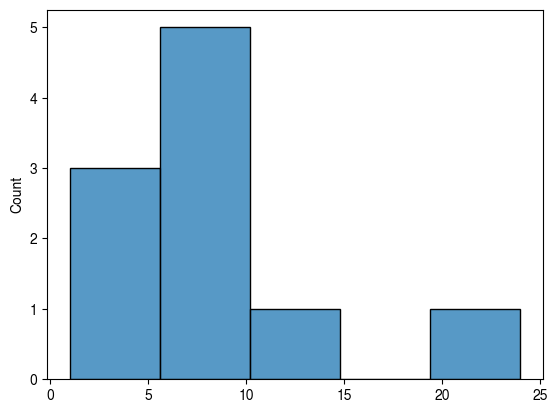

In [73]:
sns.histplot(num_hits_of_2_descendants_of_1)
plt.show()


<Axes: ylabel='Count'>

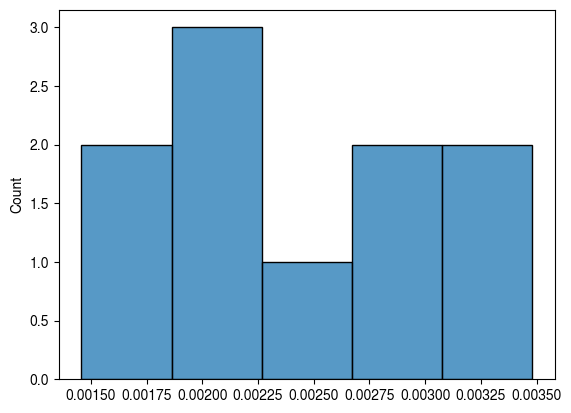

In [74]:
sns.histplot(energies_of_2_descendants_of_1)

In [119]:
failing_particles = []
all_pass = True

for particle in results['only_in_1']:

    if particle[0].created_inside_tracker:
        passes_test = particle[0].get_num_tracker_hits() ==0 and particle[0].kinetic_energy < 0.001
    
    else:
        passes_test = particle[0].get_num_calo_hits() ==0 or particle[0].kinetic_energy < 0.001

    print(f"Pass test: {passes_test}")
    all_pass = all_pass and passes_test
    if not passes_test:
        failing_particles.append(particle)
        print(particle[0].status_bits)
        print(particle[0].p, particle[0].kinetic_energy, particle[0].get_num_tracker_hits(), particle[0].get_num_calo_hits(), particle[0].created_inside_tracker, particle[0].ended_inside_tracker)

print(f"All pass: {all_pass}")

Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass test: True
Pass tes

In [85]:
failing_particles

[(<Particle id=21 pdg=2112 p=0.03 pT=0.03 eta=-0.74>, None),
 (<Particle id=22 pdg=1000060120 p=0.05 pT=0.05 eta=-0.27>, None),
 (<Particle id=25 pdg=2212 p=0.03 pT=0.03 eta=0.12>, None),
 (<Particle id=26 pdg=2212 p=0.02 pT=0.01 eta=1.48>, None),
 (<Particle id=28 pdg=11 p=0.00 pT=0.00 eta=0.32>, None),
 (<Particle id=29 pdg=2112 p=0.03 pT=0.03 eta=0.57>, None),
 (<Particle id=32 pdg=1000140290 p=0.08 pT=0.07 eta=0.55>, None),
 (<Particle id=34 pdg=2212 p=0.02 pT=0.01 eta=-1.06>, None),
 (<Particle id=176 pdg=2212 p=0.03 pT=0.02 eta=-0.55>, None),
 (<Particle id=177 pdg=2212 p=0.02 pT=0.00 eta=2.83>, None),
 (<Particle id=178 pdg=2212 p=0.03 pT=0.03 eta=0.19>, None),
 (<Particle id=180 pdg=2212 p=0.02 pT=0.02 eta=-0.28>, None),
 (<Particle id=181 pdg=1000140280 p=0.07 pT=0.06 eta=-0.35>, None),
 (<Particle id=183 pdg=2112 p=0.01 pT=0.01 eta=0.67>, None),
 (<Particle id=186 pdg=2112 p=0.02 pT=0.02 eta=-0.65>, None),
 (<Particle id=188 pdg=2212 p=0.03 pT=0.03 eta=-0.21>, None),
 (<Parti

### Investigate failing particles

In [86]:
failing_particle = failing_particles[0][0]

In [90]:
failing_particle._get_data()

PDG                              2112
generatorStatus                     0
simulatorStatus            1426063360
charge                            0.0
time                        20.169943
mass                         0.939565
vx                          1192.9813
vy                          402.46735
vz                         -68.149777
px                              0.021
py                           0.014125
pz                          -0.020626
endpoint_x                1334.655602
endpoint_y                 378.288416
endpoint_z                -208.579509
parents_begin                      20
parents_end                        21
daughters_begin                   209
daughters_end                     209
pt                           0.025308
p                            0.032649
eta                         -0.744349
phi                          0.592105
vr                        1259.041044
endpoint_r                1387.230226
num_hits                            1
created_in_s

In [95]:
failing_particle.status_bits

{'created_in_simulation': True,
 'backscatter': False,
 'vertex_not_endpoint': True,
 'decayed_in_tracker': False,
 'decayed_in_calorimeter': True,
 'has_left_detector': False,
 'stopped': True,
 'overlay': False}

In [91]:
failing_particle.get_tracker_hits_df()

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt


In [93]:
failing_particle.get_calo_hits_df()

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector
16,0,0.000005,67.99485,0.0,0.0,0.0,21,4,1273.891113,395.178131,-127.5,ECalBarrelCollection


## Some Questions...

1. Are there virtual particles in the tracker between, e.g. a primary, and a decay product that leaves a hit?

In [ ]:
# Want to get a particle that starts and ends in the tracker, which doesn't leave a hit, but has a decay product that does.

In [ ]:
full_tracker_df

In [ ]:
full_particles_df.columns

In [ ]:
full_particles_df["left_tracker_hit"] = full_particles_df.index.isin(full_tracker_df.particle_id)

In [ ]:
particles_without_hit_with_daughters_mask = ~full_particles_df.left_tracker_hit & (full_particles_df.daughters_begin != full_particles_df.daughters_end) & full_particles_df.created_inside_tracker & full_particles_df.ended_inside_tracker
particles_without_hit_with_daughters = full_particles_df[particles_without_hit_with_daughters_mask]

In [ ]:
particles_without_hit_with_daughters

In [ ]:
# sample = 4

for sample in particles_without_hit_with_daughters.index:
    daughters_indices = full_daughters_df[full_particles_df.loc[sample].daughters_begin:full_particles_df.loc[sample].daughters_end]
    daughters = full_particles_df.loc[daughters_indices.particle_id]
    
    parents_indices = full_parents_df[full_particles_df.loc[sample].parents_begin:full_particles_df.loc[sample].parents_end]
    parents = full_particles_df.loc[parents_indices.particle_id]
    
    # if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0:
    #     break

    if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0 and parents.left_tracker_hit.any():
        print("Found one!")
        break

In [ ]:
sample

In [ ]:
full_particles_df.loc[sample]

In [ ]:
daughters

In [ ]:
full_particles_df.loc[32]

In [ ]:
ancestors = list(nx.ancestors(G, sample))
descendants = list(nx.descendants(G, sample))

In [ ]:
ancestors

In [ ]:
descendants

In [ ]:
plt.figure(figsize=(20, 20))
plt.scatter(full_particles_df.loc[ancestors].vz, full_particles_df.loc[ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(full_particles_df.loc[descendants].vz, full_particles_df.loc[descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")

plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].z, full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].r, c="red", s=10, label="Ancestors hits")
plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(descendants)].z, full_tracker_df[full_tracker_df.particle_id.isin(descendants)].r, c="black", s=10, label="Descendants hits")

plt.scatter(full_particles_df.loc[sample].vz, full_particles_df.loc[sample].vr, c="green", s=10, marker="x", label="Sample particle")
plt.scatter(full_tracker_df[full_tracker_df.particle_id == sample].z, full_tracker_df[full_tracker_df.particle_id == sample].r, c="green", s=1, label="Sample particle")

# add tracker boundaries
tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']
plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
    

plt.legend()
plt.show()
